Строк: 601 Столбцов: 12
ТИПЫ ПРИЗНАКОВ:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object
fixed_acidity           39
volatile_acidity        30
citric_acid             16
residual_sugar          12
chlorides               26
free_sulfur_dioxide     15
total_sulfur_dioxide    20
density                 33
pH                      27
sulphates               15
alcohol                 40
quality                  0
dtype: int64
Распределение классов:
По количеству обьектов принадлежащих классу: quality_score
среднее    215
хорошее    195
плохое     191
Name: count, dtype: int64 
В процентах:
 quality_score
среднее    35.77
хорошее    32.45
плохое   

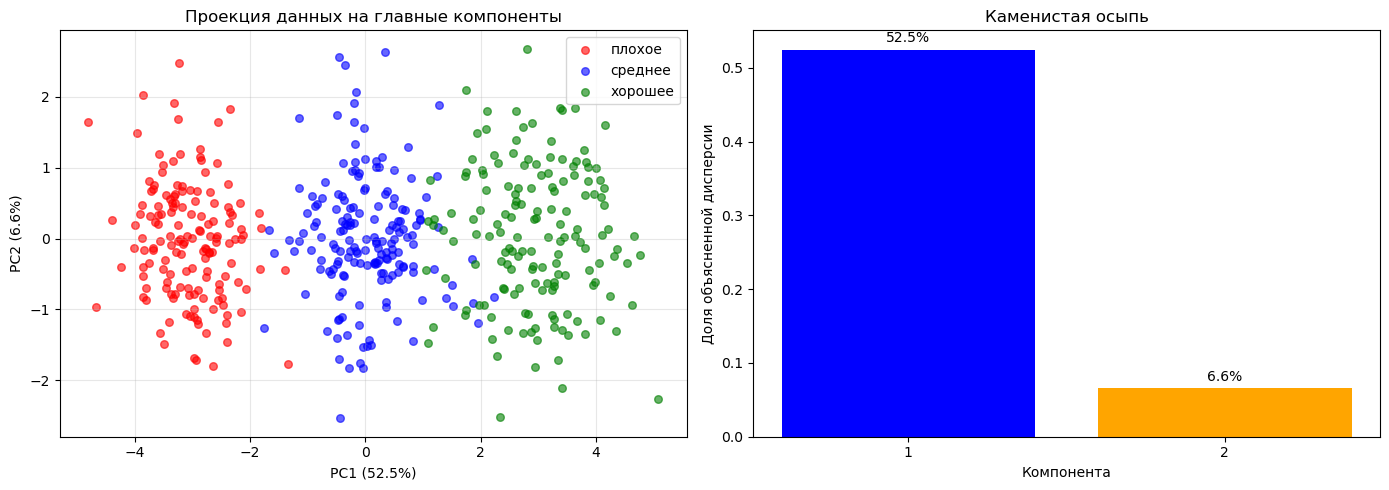

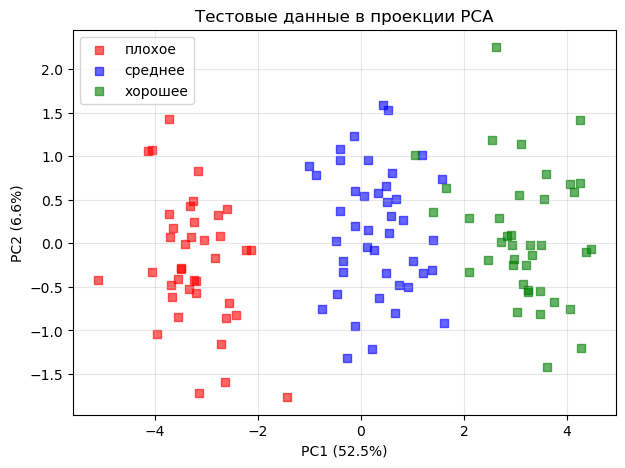

0.9669421487603306
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       0.98      0.93      0.95        43
           2       0.93      0.97      0.95        39

    accuracy                           0.97       121
   macro avg       0.97      0.97      0.97       121
weighted avg       0.97      0.97      0.97       121



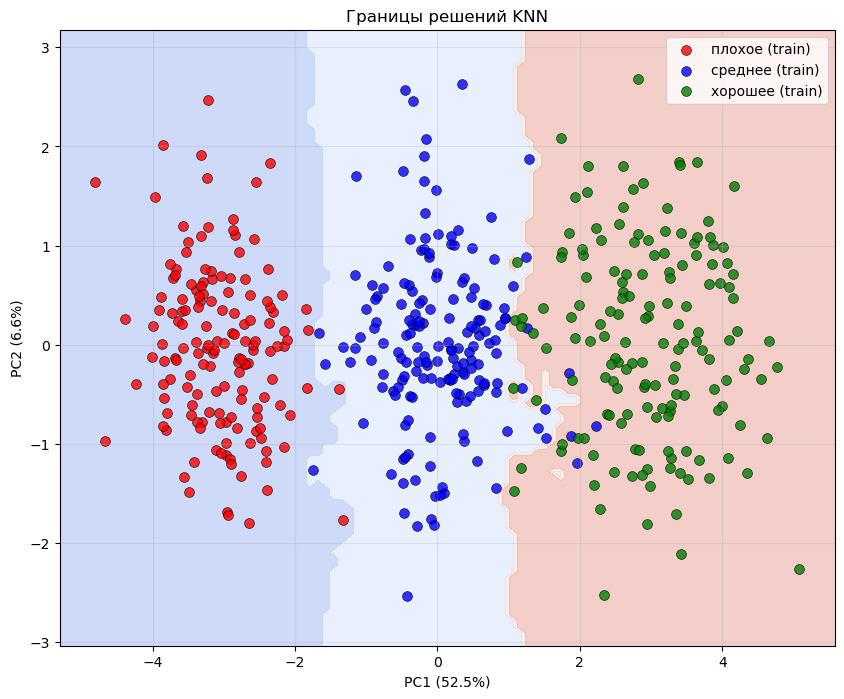

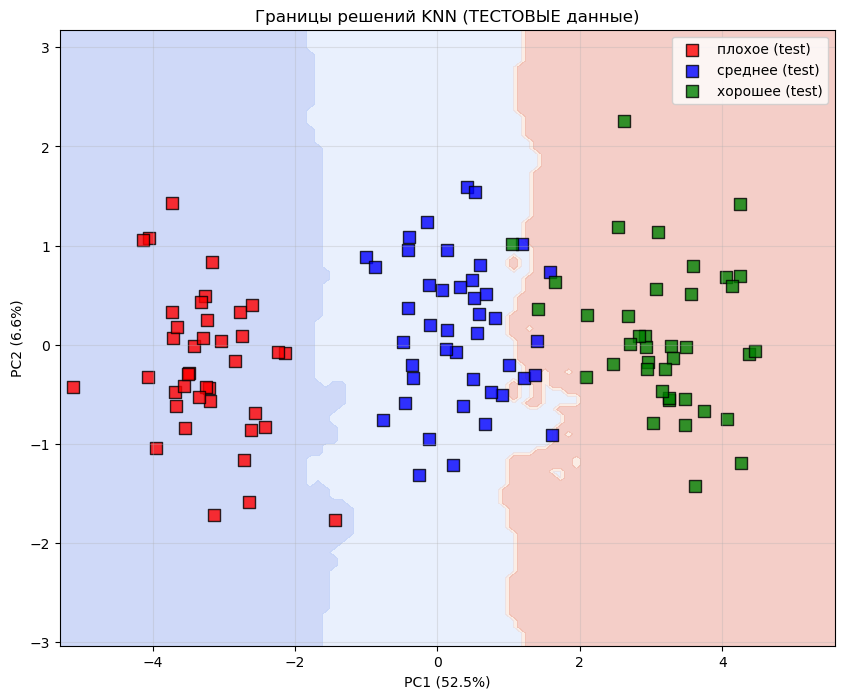

In [25]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import sklearn as sk
import numpy as np
import matplotlib as mp
import seaborn as sb
df = pd.read_csv('wine_dataset.csv')
print(f"Строк: {df.shape[0]} Столбцов: {df.shape[1]}")
print("ТИПЫ ПРИЗНАКОВ:")
print(df.dtypes)
print(df.isnull().sum())
df.fillna(df.median(), inplace=True)
def quality_to_word(quality_score):
    if quality_score <= 4:
        return 'плохое'
    elif quality_score <= 6:
        return 'среднее'
    else:
        return 'хорошее'
df['quality_score'] = df['quality'].apply(quality_to_word)
total = len(df)
print("Распределение классов:\nПо количеству обьектов принадлежащих классу:", 
      df['quality_score'].value_counts(), "\nВ процентах:\n", 
      (df['quality_score'].value_counts()*100/total).round(2))
le = LabelEncoder()
df['quality_encoded'] = le.fit_transform(df['quality_score'])
df = df.drop('quality_score', axis=1)  # старый текстовый удаляем
from sklearn.preprocessing import StandardScaler  
from sklearn.decomposition import PCA 
from sklearn.model_selection import train_test_split  
import matplotlib.pyplot as plt 
X = df.drop('quality_encoded', axis=1) 
y = df['quality_encoded'] 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                       
    test_size=0.2,              
    random_state=42,            
    stratify=y                  
)  
print(f"\nРазмер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк")
print(f"Количество признаков: {X_train.shape[1]}")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nМасштабирование выполнено")
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"\nРазмерность после PCA:")
print(f"Train: {X_train_pca.shape[1]} компоненты")
print(f"Test: {X_test_pca.shape[1]} компоненты")

explained_variance = pca.explained_variance_ratio_
print(f"\nДоля сохраненной информации:")
print(f"PC1: {explained_variance[0]:.2%}")
print(f"PC2: {explained_variance[1]:.2%}")
print(f"Всего сохранено: {explained_variance.sum():.2%}")

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
colors = ['red', 'blue', 'green']















# Рисуем точки для каждого класса по отдельности (чтобы была легенда)
for class_value in [0, 1, 2]:
    # Создаем маску: True для строк, где y_train == class_value
    mask_train = y_train == class_value
    
    # Получаем имя класса из encoder'а
    class_name = le.inverse_transform([class_value])[0]
    # inverse_transform() превращает число обратно в текст.
    # Мы передаем [class_value] в списке, потому что метод ожидает список.
    # Получаем массив, берем первый элемент [0].
    
    # Рисуем точки этого класса
    plt.scatter(
        X_train_pca[mask_train, 0],  # все строки с маской True, колонка 0 (PC1)
        X_train_pca[mask_train, 1],  # колонка 1 (PC2)
        c=colors[class_value],       # цвет
        label=class_name,            # подпись в легенде
        alpha=0.6,                   # прозрачность (0=прозрачный, 1=непрозрачный)
        s=30                         # размер точек
    )

plt.xlabel(f'PC1 ({explained_variance[0]:.1%})')  # подпись оси X
plt.ylabel(f'PC2 ({explained_variance[1]:.1%})')  # подпись оси Y
plt.title('Проекция данных на главные компоненты')  # заголовок
plt.legend()                                         # показать легенду
plt.grid(True, alpha=0.3)                           # сетка с прозрачностью

# Второй подграфик: каменистая осыпь (сколько информации в каждой компоненте)
plt.subplot(1, 2, 2)
plt.bar(
    [1, 2],                    # координаты по X (первая и вторая компонента)
    explained_variance,        # высота столбиков (доли информации)
    color=['blue', 'orange']
)
plt.xlabel('Компонента')
plt.ylabel('Доля объясненной дисперсии')
plt.title('Каменистая осыпь')
plt.xticks([1, 2])  # подписи под столбиками

# Добавляем числа на столбики
for i, v in enumerate(explained_variance):
    plt.text(i+1, v + 0.01, f'{v:.1%}', ha='center')
    # text(x, y, текст) — добавляет текст в координаты (x, y)
    # ha='center' — выравнивание по центру

plt.tight_layout()
# tight_layout() автоматически подгоняет расстояния, чтобы графики не налезали друг на друга

plt.show()
# show() отображает все созданные графики

# =====================================================================
# 6. ВИЗУАЛИЗАЦИЯ ТЕСТОВЫХ ДАННЫХ (ДЛЯ СРАВНЕНИЯ)
# =====================================================================

plt.figure(figsize=(7, 5))
for class_value in [0, 1, 2]:
    mask_test = y_test == class_value
    class_name = le.inverse_transform([class_value])[0]
    plt.scatter(
        X_test_pca[mask_test, 0],
        X_test_pca[mask_test, 1],
        c=colors[class_value],
        label=class_name,
        alpha=0.6,
        s=30,
        marker='s'  # маркер 's' — квадрат (для отличия от train)
    )

plt.xlabel(f'PC1 ({explained_variance[0]:.1%})')
plt.ylabel(f'PC2 ({explained_variance[1]:.1%})')
plt.title('Тестовые данные в проекции PCA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

from sklearn.neighbors import KNeighborsClassifier 

from sklearn.metrics import accuracy_score, classification_report

model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
     algorithm='auto',
    metric='euclidean'
)
model.fit(X_train_pca, y_train)
y_predict = model.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_predict)

print(accuracy)
print(classification_report(y_test, y_predict))


# =====================================================================
# КАРТА ГРАНИЦ РЕШЕНИЙ (DECISION BOUNDARIES)
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

# Создаем сетку точек во всем пространстве PC1-PC2
# Берем минимальные и максимальные значения PC1 и PC2 из train
x_min, x_max = X_train_pca[:, 0].min() - 0.5, X_train_pca[:, 0].max() + 0.5
y_min, y_max = X_train_pca[:, 1].min() - 0.5, X_train_pca[:, 1].max() + 0.5

# Создаем сетку 100x100 точек
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

# Для каждой точки сетки предсказываем класс
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Рисуем границы
plt.figure(figsize=(10, 8))

# Закрашиваем области
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm', levels=3)

# Добавляем обучающие точки
for class_value in [0, 1, 2]:
    mask_train = y_train == class_value
    class_name = le.inverse_transform([class_value])[0]
    plt.scatter(
        X_train_pca[mask_train, 0],
        X_train_pca[mask_train, 1],
        c=colors[class_value],
        label=f'{class_name} (train)',
        alpha=0.8,
        s=50,
        edgecolors='black',
        linewidth=0.5
    )

plt.xlabel(f'PC1 ({explained_variance[0]:.1%})')
plt.ylabel(f'PC2 ({explained_variance[1]:.1%})')
plt.title('Границы решений KNN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()










# =====================================================================
# КАРТА ГРАНИЦ РЕШЕНИЙ С ТЕСТОВЫМИ ТОЧКАМИ
# =====================================================================

plt.figure(figsize=(10, 8))

# Закрашиваем области (те же самые, что и на первой карте)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm', levels=3)

# Добавляем ТЕСТОВЫЕ точки
for class_value in [0, 1, 2]:
    mask_test = y_test == class_value
    class_name = le.inverse_transform([class_value])[0]
    plt.scatter(
        X_test_pca[mask_test, 0],
        X_test_pca[mask_test, 1],
        c=colors[class_value],
        label=f'{class_name} (test)',
        alpha=0.8,
        s=70,  # чуть больше, чем train
        edgecolors='black',
        linewidth=1,
        marker='s'  # квадратики, чтобы отличить от train
    )

plt.xlabel(f'PC1 ({explained_variance[0]:.1%})')
plt.ylabel(f'PC2 ({explained_variance[1]:.1%})')
plt.title('Границы решений KNN (ТЕСТОВЫЕ данные)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()